In [1]:
# Spotify Song Recommendation System
# Step 1 - Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Save Model
import joblib

In [2]:
# Step 2 - Load Dataset

df = pd.read_csv("../Datasets/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.shape

(114000, 21)

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [6]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [8]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [9]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [12]:
df.drop(
    columns=[
        "Unnamed: 0",
        "track_id"
    ],
    inplace=True
)


In [13]:
df.drop(columns=["Unnamed: 0", "track_id"], errors="ignore", inplace=True)

In [14]:
df.fillna("", inplace=True)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [15]:
# Remove rows with missing values
df.dropna(subset=["artists", "album_name", "track_name"], inplace=True)

In [16]:
df.isnull().sum()

artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [17]:
print("Number of Songs :", len(df))
print("Number of Artists :", df["artists"].nunique())
print("Number of Albums :", df["album_name"].nunique())
print("Number of Genres :", df["track_genre"].nunique())

Number of Songs : 114000
Number of Artists : 31438
Number of Albums : 46590
Number of Genres : 114


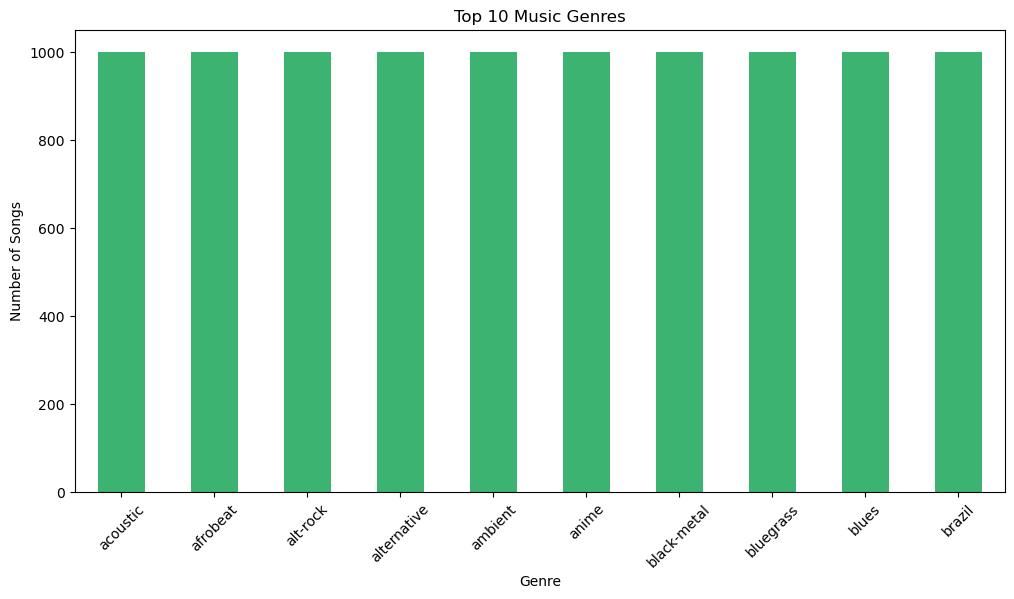

In [18]:
plt.figure(figsize=(12,6))

df["track_genre"].value_counts().head(10).plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Top 10 Music Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")

plt.xticks(rotation=45)

plt.show()

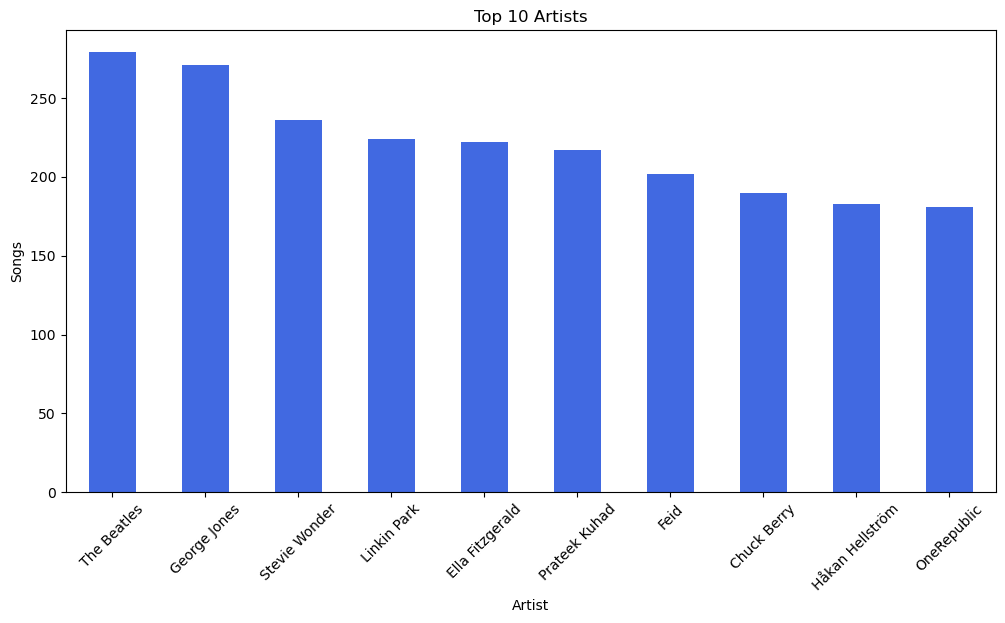

In [19]:
plt.figure(figsize=(12,6))

df["artists"].value_counts().head(10).plot(
    kind="bar",
    color="royalblue"
)

plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Songs")

plt.xticks(rotation=45)

plt.show()

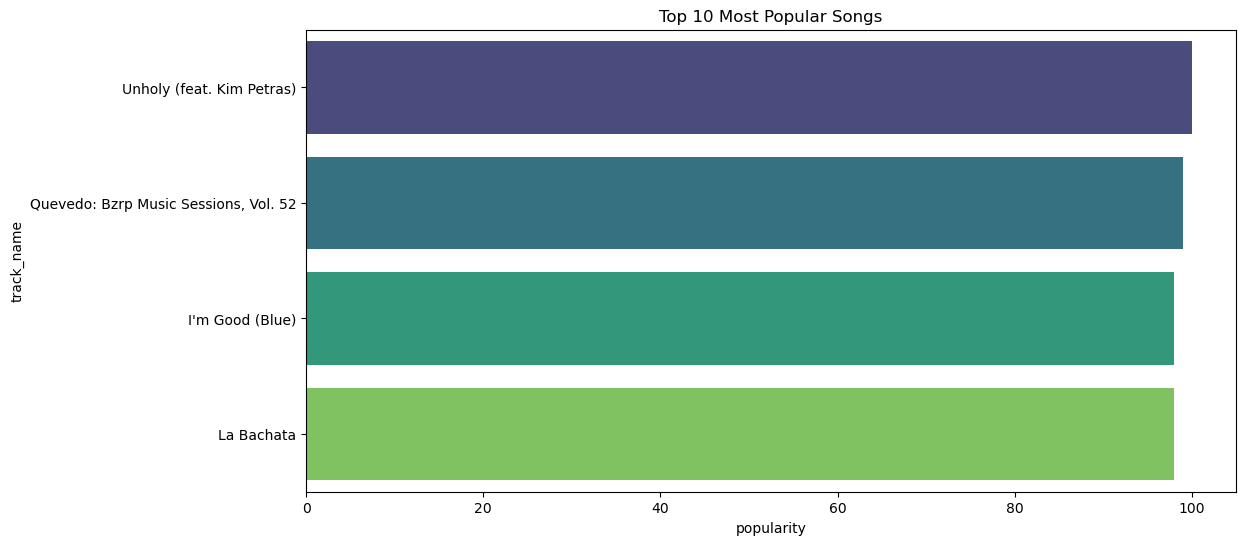

In [20]:
top_songs = df.sort_values(
    by="popularity",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_songs,
    x="popularity",
    y="track_name",
    palette="viridis"
)

plt.title("Top 10 Most Popular Songs")

plt.show()

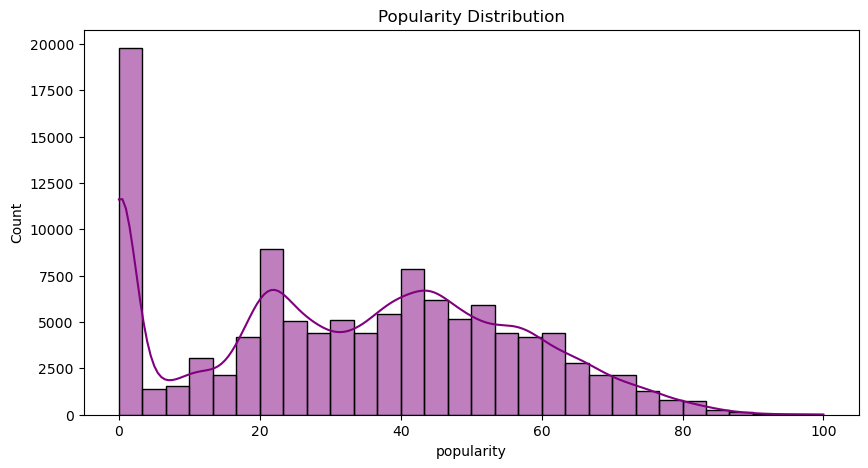

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Popularity Distribution")

plt.show()

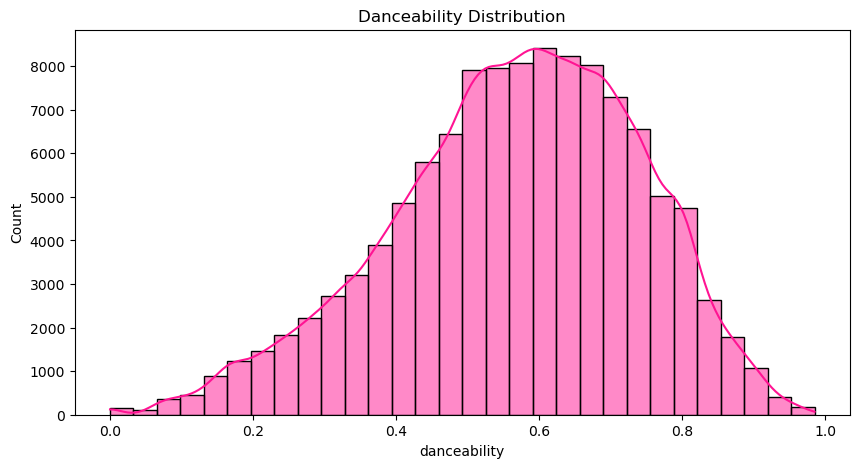

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["danceability"],
    bins=30,
    kde=True,
    color="deeppink"
)

plt.title("Danceability Distribution")

plt.show()

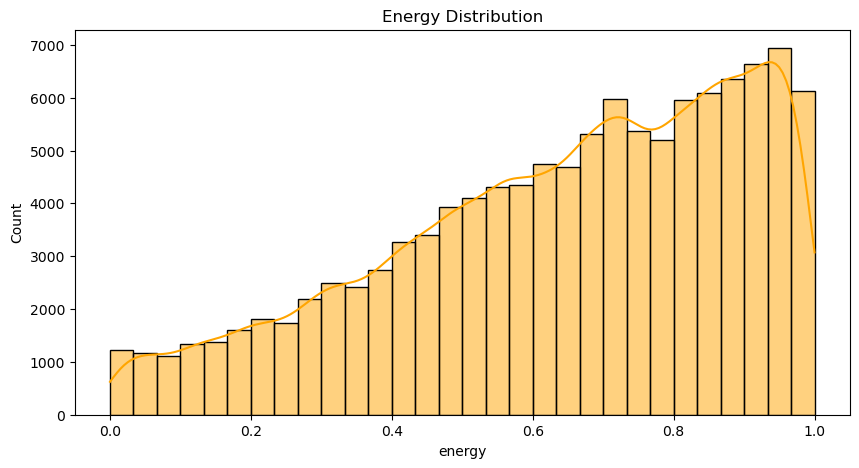

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["energy"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Energy Distribution")

plt.show()

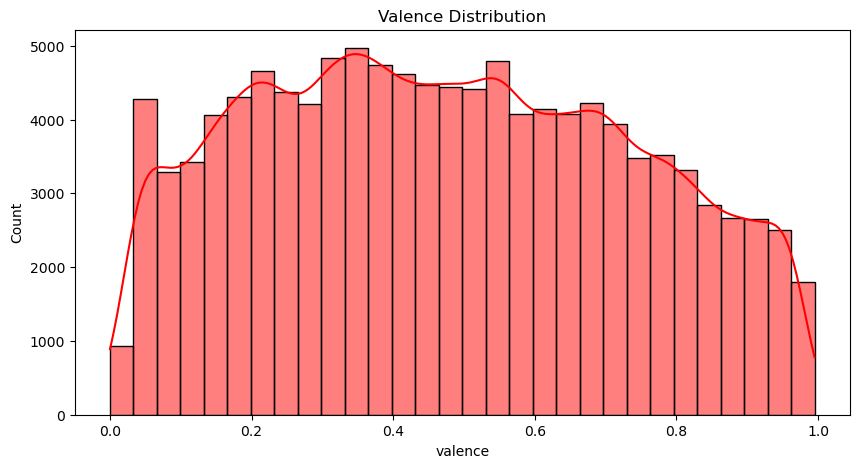

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["valence"],
    bins=30,
    kde=True,
    color="red"
)

plt.title("Valence Distribution")

plt.show()

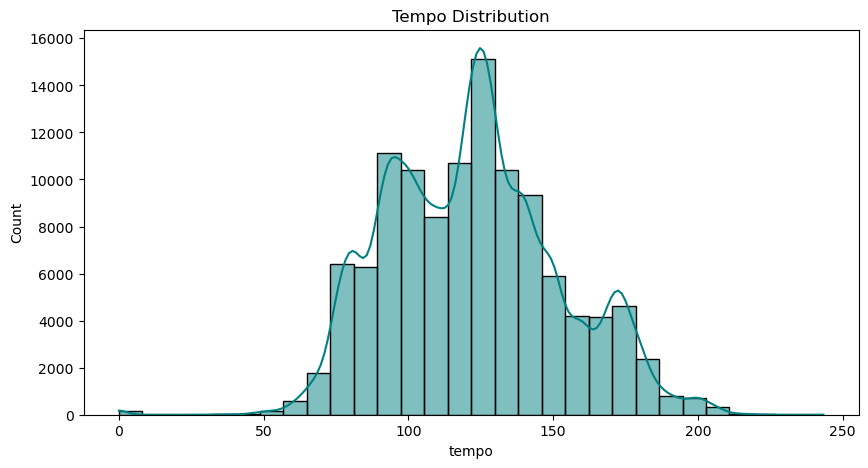

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["tempo"],
    bins=30,
    kde=True,
    color="teal"
)

plt.title("Tempo Distribution")

plt.show()

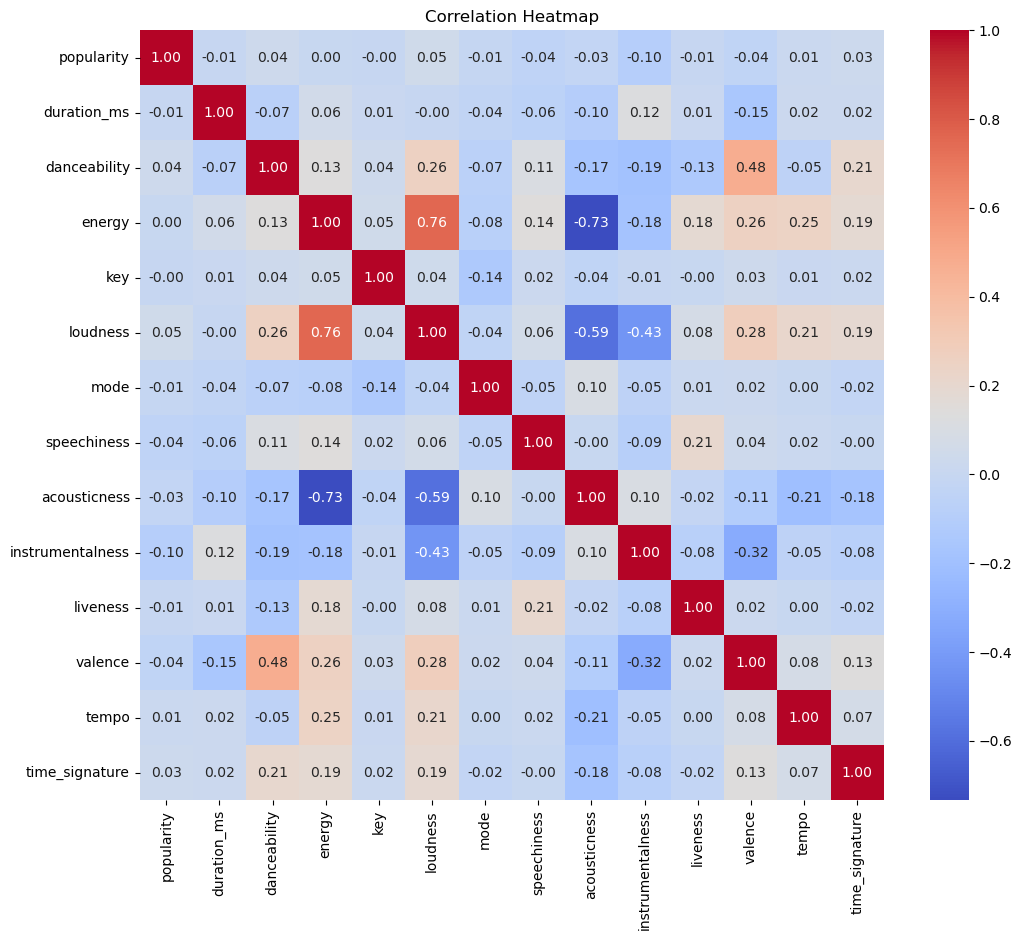

In [26]:
plt.figure(figsize=(12,10))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

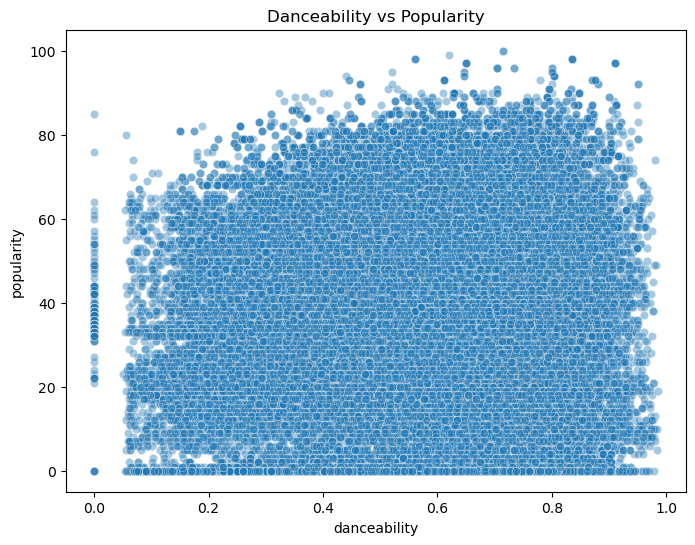

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="popularity",
    alpha=0.4
)

plt.title("Danceability vs Popularity")

plt.show()

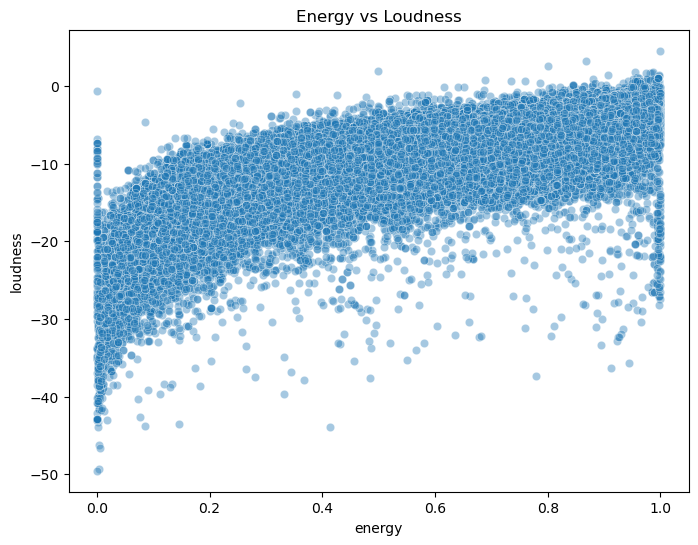

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="energy",
    y="loudness",
    alpha=0.4
)

plt.title("Energy vs Loudness")

plt.show()

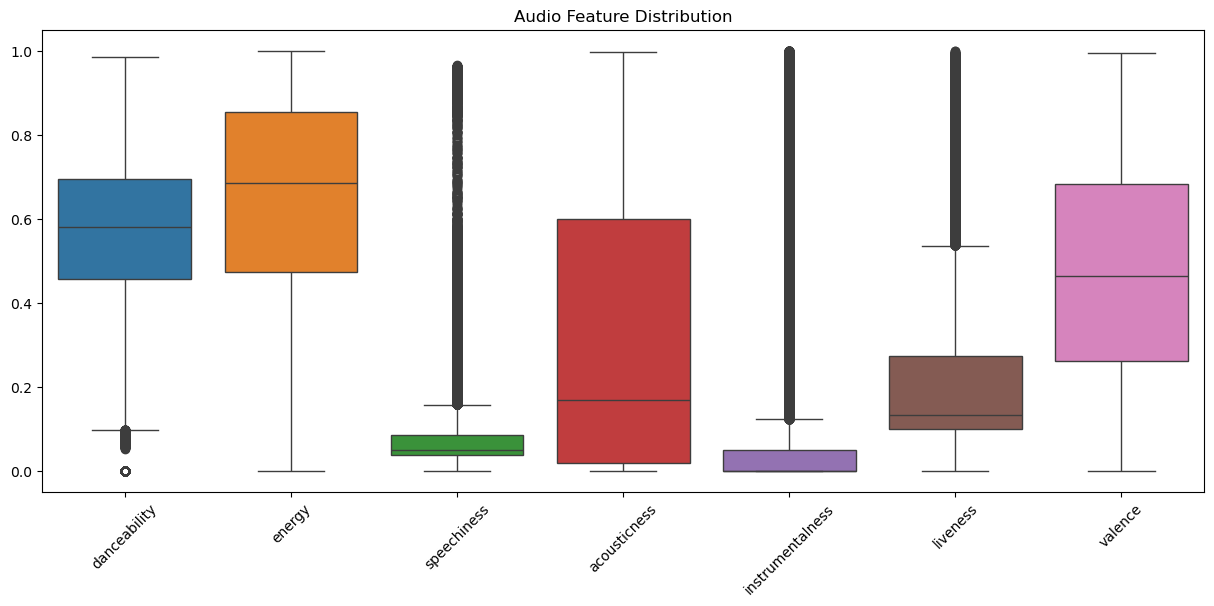

In [29]:
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

plt.figure(figsize=(15,6))

sns.boxplot(data=df[audio_features])

plt.xticks(rotation=45)

plt.title("Audio Feature Distribution")

plt.show()

In [30]:
# Step 6 - Select Audio Features
features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

X = df[features]

X.head()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


In [31]:
# Step 7 - Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
print(X_scaled.shape)

(114000, 14)


In [33]:
from sklearn.preprocessing import StandardScaler

features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape :", X_scaled.shape)

Shape : (114000, 14)


In [34]:
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=6
)

model.fit(X_scaled)

print("Recommendation model trained successfully!")

Recommendation model trained successfully!


In [35]:
def recommend_songs(song_name, n_recommendations=5):

    # Find the song
    song = df[df["track_name"].str.lower() == song_name.lower()]

    if song.empty:
        return "Song not found!"

    # Get index
    idx = song.index[0]

    # Find nearest neighbours
    distances, indices = model.kneighbors(
        [X_scaled[idx]],
        n_neighbors=n_recommendations + 1
    )

    recommendations = []

    for i in indices[0][1:]:

        recommendations.append({
            "Song": df.iloc[i]["track_name"],
            "Artist": df.iloc[i]["artists"],
            "Album": df.iloc[i]["album_name"],
            "Genre": df.iloc[i]["track_genre"],
            "Popularity": df.iloc[i]["popularity"]
        })

    return pd.DataFrame(recommendations)

In [36]:
df["track_name"].sample(20, random_state=42)

113186                                        No Other Name
42819                                        Failed Organum
59311                                 Save the Trees, Pt. 1
91368                                       Merry Christmas
61000                                                 月の大きさ
96815                                Jah Jah Revolta, Pt. 2
18939                             Please Stop Communicating
72760                                     A Form of Protest
25788                                I'm Ready - Radio Edit
87169                   Proibida Pra Mim (Grazon) - Ao Vivo
19261     I'll Be Home For Christmas - From The Kacey Mu...
62735                                                 時間がない
108051                                                  Sur
77161     Pega pega (Participação especial de Jojo Maron...
115                                 In Case You Didn’t Know
87994                                       O Sopro do Fole
96569                     Vi Mamãe Oxum 

In [37]:
recommend_songs("Shape of You")

,Song,Artist,Album,Genre,Popularity
0,Life Is Just a Bowl of Cherries,Jack Hylton & His Orchestra,On the Sunny Side of the Street (1930-1931),j-dance,23
1,Yaramaz Ne Oldu Sana,Mavi Işıklar,Mavi Işıklar - Türk Pop Tarihi,psych-rock,26
2,Nostalgias,Florindo Sassone Y Su Orquesta,Tangos de oro,tango,16
3,Milonga Brava,Francisco Canaro;Roberto Maida,Tango Classics 234: Valsecito Amigo,tango,20
4,Imaginación,Alfredo De Angelis;Orquesta de Alfredo De Angelis,Los 25 Mejores Tangos,tango,19


In [38]:
import joblib

joblib.dump(model, "spotify_recommender.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(df, "spotify_dataset.pkl")
joblib.dump(features, "feature_columns.pkl")

print("All files saved successfully!")

All files saved successfully!


In [39]:
df[df["track_name"].str.contains("Believer", case=False, na=False)][
    ["track_name", "artists"]
].head(10)

,track_name,artists
125,Believer (Remix),Ben Woodward
2270,I'm A Believer - Radio Edit,Smash Mouth
3422,I'm A Believer - Radio Edit,Smash Mouth
15498,Believer (Remix),Ben Woodward
24505,Believer [featuring Ann Saunderson] - The Edit,Octave One
24966,I'm A Believer,Inner City;ZebrA OctobrA
27169,Believer,Friction
28125,Believer,Fairlane
29127,Believer,Fairlane
31410,Believers,Alan Walker;Conor Maynard


In [40]:
recommend_songs("Believer")

,Song,Artist,Album,Genre,Popularity
0,Rav,The Minds Of 99,The Minds Of 99,punk-rock,35
1,ninelie,Aimer;Chelly,daydream,j-rock,54
2,ninelie,Aimer;Chelly,daydream,anime,54
3,By Your Side,Friction;Flowidus;Raphaella,By Your Side,drum-and-bass,54
4,Somewhere,Grafix;Reiki Ruawai,Half Life,drum-and-bass,53
